In [12]:
!python -V

Python 3.11.9


In [13]:
import pandas as pd

In [14]:
import os
import pickle

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [17]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

with mlflow.start_run():
    mlflow.log_param("status", "testing_connection")
    print("Run recorded!")

2026/03/13 17:24:56 INFO mlflow.tracking.fluent: Experiment with name 'nyc-taxi-experiment' does not exist. Creating a new experiment.


Run recorded!


In [18]:
df = pd.read_parquet("../data/green_tripdata_2021-01.parquet")

In [19]:
df['duration']  = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td : td.total_seconds() / 60 )

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [20]:
train_dicts = df[categorical + numerical].to_dict(orient="records")

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829626

C:\Users\mae25\AppData\Local\Temp\ipykernel_3628\1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
C:\Users\mae25\AppData\Local\Temp\ipykernel_3628\1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


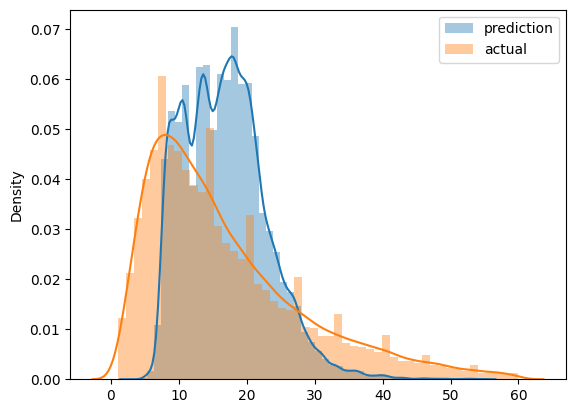

In [21]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [22]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [23]:
df_train = read_dataframe('../data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('../data/green_tripdata_2021-02.parquet')
len(df_train), len(df_val)

(73908, 61921)

In [24]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [25]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [26]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715210601492

In [28]:
# Define your directory and filename
output_dir = 'models'
file_path = os.path.join(output_dir, 'lin_reg.bin')

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [29]:
with mlflow.start_run():

    mlflow.set_tag("developer", "Mo Etman")
    mlflow.log_param("train-data-path", "../data/green_tripdata_2021-01.csv")
    mlflow.log_param("valid-data-path", "../data/green_tripdata_2021-02.csv")


    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")


#Using Xgboost

In [30]:
import xgboost as xgb


In [31]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [32]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)


In [33]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model","xgboot")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, "validation")],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [37]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=Trials()
)

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

a:\AI\mlops\experiment-tracking\experiment-tracking-env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [17:33:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.17707                          
[1]	validation-rmse:10.31643                          
[2]	validation-rmse:9.60563                           
[3]	validation-rmse:9.02294                           
[4]	validation-rmse:8.54947                           
[5]	validation-rmse:8.16587                           
[6]	validation-rmse:7.85683                           
[7]	validation-rmse:7.60856                           
[8]	validation-rmse:7.41184                           
[9]	validation-rmse:7.25275                           
[10]	validation-rmse:7.12442                          
[11]	validation-rmse:7.02177                          
[12]	validation-rmse:6.93967                          
[13]	validation-rmse:6.87413                          
[14]	validation-rmse:6.82066                          
[15]	validation-rmse:6.77765                          
[16]	validation-rmse:6.74000                          
[17]	validation-rmse:6.71105                          
[18]	valid

2026/03/13 17:36:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 10%|█         | 1/10 [03:18<29:48, 198.68s/trial, best loss: 6.4487687414198005]

...

 90%|█████████ | 9/10 [29:45<03:37, 217.24s/trial, best loss: 6.333453110840689]

a:\AI\mlops\experiment-tracking\experiment-tracking-env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:03:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.65297                                                     
[1]	validation-rmse:8.23438                                                     
[2]	validation-rmse:7.48538                                                     
[3]	validation-rmse:7.09478                                                     
[4]	validation-rmse:6.89065                                                     
[5]	validation-rmse:6.77498                                                     
[6]	validation-rmse:6.71276                                                     
[7]	validation-rmse:6.67680                                                     
[8]	validation-rmse:6.65585                                                     
[9]	validation-rmse:6.63996                                                     
[10]	validation-rmse:6.63042                                                    
[11]	validation-rmse:6.62331                                                    
[12]	validation-rmse:6.61979

2026/03/13 18:03:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



100%|██████████| 10/10 [32:04<00:00, 192.46s/trial, best loss: 6.333453110840689]


In [ ]:
mlflow.xgboost.autolog(disable=True)

In [38]:

with mlflow.start_run():
    
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.09585355369315604,
        'max_depth': 30,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.018060244040060163,
        'reg_lambda': 0.011658731377413597,
        'seed': 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

    

a:\AI\mlops\experiment-tracking\experiment-tracking-env\Lib\site-packages\xgboost\callback.py:385: UserWarning: [02:17:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:11.44482
[1]	validation-rmse:10.77202
[2]	validation-rmse:10.18363
[3]	validation-rmse:9.67396
[4]	validation-rmse:9.23166
[5]	validation-rmse:8.84808
[6]	validation-rmse:8.51883
[7]	validation-rmse:8.23597
[8]	validation-rmse:7.99320
[9]	validation-rmse:7.78709
[10]	validation-rmse:7.61022
[11]	validation-rmse:7.45952
[12]	validation-rmse:7.33049
[13]	validation-rmse:7.22098
[14]	validation-rmse:7.12713
[15]	validation-rmse:7.04752
[16]	validation-rmse:6.98005
[17]	validation-rmse:6.92232
[18]	validation-rmse:6.87112
[19]	validation-rmse:6.82740
[20]	validation-rmse:6.78995
[21]	validation-rmse:6.75792
[22]	validation-rmse:6.72994
[23]	validation-rmse:6.70547
[24]	validation-rmse:6.68390
[25]	validation-rmse:6.66421
[26]	validation-rmse:6.64806
[27]	validation-rmse:6.63280
[28]	validation-rmse:6.61924
[29]	validation-rmse:6.60773
[30]	validation-rmse:6.59777
[31]	validation-rmse:6.58875
[32]	validation-rmse:6.58107
[33]	validation-rmse:6.57217
[34]	validation-rmse:

2026/03/14 02:18:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 02:19:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [45]:
logged_model = "runs:/907b2602943d4e5aaf8a92e2a9d30b31/models_mlflow"

logged_model = mlflow.pyfunc.load_model(logged_model)

In [46]:
logged_model

mlflow.pyfunc.loaded_model:
  artifact_path: file:///a:/AI/mlops/experiment-tracking/mlruns/1/models/m-f6bbf735919149f1abbd699ce02a6d67/artifacts
  flavor: mlflow.xgboost
  run_id: 907b2602943d4e5aaf8a92e2a9d30b31

In [48]:
xgboost_model = mlflow.xgboost.load_model("runs:/907b2602943d4e5aaf8a92e2a9d30b31/models_mlflow")

In [49]:
y_pred = xgboost_model.predict(valid)

In [50]:
y_pred[:10]

array([14.782765 ,  7.184751 , 15.971323 , 24.328938 ,  9.559302 ,
       17.115105 , 11.6522455,  8.688133 ,  8.962229 , 18.982166 ],
      dtype=float32)

In [1]:
from mlflow.tracking import MlflowClient


MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [3]:
client.create_experiment(name="test")

'2'

In [ ]:
from mlflow.entities import ViewType

runs = client.search_runs(
    experiment_ids='1',
    filter_string="metrics.rmse < 6.8",
    run_view_type=ViewType.ACTIVE_ONLY,
    max_results=5,
    order_by=["metrics.rmse ASC"]
)

In [14]:
for runs in runs:
    print(f"run id: {runs.info.run_id}, rmse: {runs.data.metrics['rmse']:.4f}")

run id: 907b2602943d4e5aaf8a92e2a9d30b31, rmse: 6.3184
run id: c3bc486d4b9343a696ac9a394b3c6436, rmse: 6.3184
run id: 95969795ad8c413eb3c1d1e0177c689e, rmse: 6.3335
run id: 07efb31a1cdf4cd39c9ae96a90331566, rmse: 6.3662
run id: 4d8f0059ae274bffb95c5aed869ef3b1, rmse: 6.3759


In [15]:
import mlflow

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

In [16]:
run_id = "4d8f0059ae274bffb95c5aed869ef3b1"
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri=model_uri, name="nyc-taxi-regressor")

Registered model 'nyc-taxi-regressor' already exists. Creating a new version of this model...
2026/03/15 00:23:17 WARNING mlflow.tracking._model_registry.fluent: Run with id 4d8f0059ae274bffb95c5aed869ef3b1 has no artifacts at artifact path 'model', registering model based on models:/m-ec0deeb89ab1481e9a75b5febdb3961a instead
Created version '3' of model 'nyc-taxi-regressor'.


<ModelVersion: aliases=[], creation_timestamp=1773526997706, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1773526997706, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4d8f0059ae274bffb95c5aed869ef3b1', run_link=None, source='models:/m-ec0deeb89ab1481e9a75b5febdb3961a', status='READY', status_message=None, tags={}, user_id=None, version=3, workspace='default'>

In [17]:
model_name = "nyc-taxi-regressor"
latest_versions = client.get_latest_versions(name=model_name)


for version in latest_versions:
    print(f"version: {version.version}, stage: {version.current_stage}")

version: 3, stage: None


C:\Users\mae25\AppData\Local\Temp\ipykernel_2112\3828318741.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_versions = client.get_latest_versions(name=model_name)


In [18]:
client.transition_model_version_stage(
    name=model_name,
    version=3,
    stage="Staging",
    archive_existing_versions=False
)

C:\Users\mae25\AppData\Local\Temp\ipykernel_2112\3248838605.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1773526997706, current_stage='Staging', deployment_job_state=None, description=None, last_updated_timestamp=1773527334859, metrics=None, model_id=None, name='nyc-taxi-regressor', params=None, run_id='4d8f0059ae274bffb95c5aed869ef3b1', run_link=None, source='models:/m-ec0deeb89ab1481e9a75b5febdb3961a', status='READY', status_message=None, tags={}, user_id=None, version=3, workspace='default'>